# BAT Plus: Batting Quality Model

This notebook builds a season-adjusted **BAT Plus** score from swing and contact measures, then evaluates how consistently the score carries from one season to the next.

## 1. Setup and data loading

Place `batquality.csv` in the same folder as this notebook before running it. The analysis uses player-season observations and keeps only complete records for the needed fields.

In [1]:
# Import analysis, modeling, and visualization libraries.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Read the player-season source data from the notebook directory.
data_path = Path('batqualitydata.csv')
df = pd.read_csv(data_path)
print(f'Loaded {len(df):,} rows and {len(df.columns)} columns from {data_path.name}.')

Loaded 1,782 rows and 55 columns from batqualitydata.csv.


## 2. Prepare features

Traditional batting measures are standardized into a consistent set of column names. The swing and contact inputs are then converted to within-season z-scores, which makes values comparable across seasons.

In [2]:
# Create consistently named traditional batting metrics.
df['obp'] = df['on_base_percent']
df['slug'] = df['slg_percent']
df['iso'] = df['slug'] - df['obp']
df['squared_up'] = df['squared_up_conta']

required_cols = [
    'fast_swing_rate', 'h_contact', 's_contact', 'c_contact', 'h_swing', 's_swing', 'c_swing',
    'w_swing', 'season', 'xwoba', 'woba', 'obp', 'slug', 'iso', 'avg', 'bb_percent', 'squared_up',
    'pa', 'player_id', 'name',
]

# Keep complete observations so every later model uses the same sample.
data = df.dropna(subset=required_cols).copy()
print(f'Analysis sample: {len(data):,} complete player-season records.')

feature_cols = ['fast_swing_rate', 'h_contact', 's_contact', 'c_contact', 'h_swing', 's_swing', 'c_swing', 'w_swing']
for col in feature_cols:
    # Standardize within season to remove league-level year-to-year shifts.
    data[f'{col}_z'] = data.groupby('season')[col].transform(
        lambda values: (values - values.mean()) / values.std()
    )


Analysis sample: 1,764 complete player-season records.


## 3. Derive the swing-decision index

An OLS fit estimates how each standardized swing-decision input relates to Walk Percentage. Those fitted coefficients become the weights for the composite decision index. Variance inflation factors (VIFs) provide a simple multicollinearity check.

In [3]:
from scipy.optimize import LinearConstraint, minimize

swing_features = ['h_swing_z', 's_swing_z', 'c_swing_z', 'w_swing_z']
X_obp = data[swing_features]
y_obp = data['bb_percent']

# Start with the ordinary OLS solution, then apply baseball-informed constraints.
ols_weights = LinearRegression().fit(X_obp, y_obp).coef_

X_values = X_obp.to_numpy()
y_values = y_obp.to_numpy()

# Centering accounts for the model intercept while optimizing only the weights.
X_centered = X_values - X_values.mean(axis=0)
y_centered = y_values - y_values.mean()

def objective(weights):
    residuals = y_centered - X_centered @ weights
    return np.mean(residuals ** 2)

def gradient(weights):
    residuals = y_centered - X_centered @ weights
    return (-2 / len(y_centered)) * X_centered.T @ residuals

# Coefficient order: Heart, Shadow, Chase, Waste
minimum_waste_penalty = 0.001

# Enforce:
# Waste <= Chase - minimum_waste_penalty <= Shadow <= Heart
constraint_matrix = np.array([
    [0,  0,  1, -1],  # Chase - Waste >= minimum_waste_penalty
    [0,  1, -1,  0],  # Shadow - Chase >= 0
    [1, -1,  0,  0],  # Heart - Shadow >= 0
])

weight_constraints = LinearConstraint(
    constraint_matrix,
    lb=[minimum_waste_penalty, 0, 0],
    ub=[np.inf, np.inf, np.inf],
)

result = minimize(
    objective,
    x0=ols_weights,
    jac=gradient,
    constraints=[weight_constraints],
    method='SLSQP',
)

if not result.success:
    raise RuntimeError(f'Constrained weight optimization failed: {result.message}')

w_heart, w_shadow, w_chase, w_waste = result.x

print('=== Constrained OBP Regression-Derived Swing Weights ===')
for label, weight in zip(
    ['Heart', 'Shadow', 'Chase', 'Waste'],
    [w_heart, w_shadow, w_chase, w_waste],
):
    print(f'{label:>6}: {weight:+.6f}')

# Calculate VIF values on the original swing-decision feature matrix.
X_obp_const = sm.add_constant(X_obp)
vif_obp = pd.DataFrame({
    'Feature': swing_features,
    'VIF': [
        variance_inflation_factor(X_obp_const.values, index)
        for index in range(1, X_obp_const.shape[1])
    ],
})
display(vif_obp.style.format({'VIF': '{:.2f}'}))

# Apply the fitted coefficients directly.
# Do not negate Shadow, Chase, or Waste here: their constrained coefficients
# already encode their negative contribution to the decision index.
data['decision_idx_raw'] = (
    w_heart * data['h_swing_z']
    + w_shadow * data['s_swing_z']
    + w_chase * data['c_swing_z']
    + w_waste * data['w_swing_z']
)

data['decision_index_z'] = data.groupby('season')['decision_idx_raw'].transform(
    lambda values: (values - values.mean()) / values.std()
)

# Compute fitted values and residuals for the constrained model
y_pred_centered = X_centered @ result.x

# Calculate Sum of Squared Residuals (SSR) and Total Sum of Squares (SST)
ssr = np.sum((y_centered - y_pred_centered) ** 2)
sst = np.sum(y_centered ** 2)

# Calculate R^2 and R
r_squared = 1 - (ssr / sst)
r_value = np.sqrt(max(0, r_squared)) * np.sign(np.corrcoef(y_centered, y_pred_centered)[0, 1])

print(f"\nModel Performance Metrics:")
print(f"R-squared (R²): {r_squared:.4f}")
print(f"R-value (r)   : {r_value:+.4f}")

=== Constrained OBP Regression-Derived Swing Weights ===
 Heart: +0.160454
Shadow: -0.812525
 Chase: -0.812525
 Waste: -0.813525


,Feature,VIF
0,h_swing_z,1.68
1,s_swing_z,3.66
2,c_swing_z,3.19
3,w_swing_z,1.68



Model Performance Metrics:
R-squared (R²): 0.4552
R-value (r)   : +0.6747


## 4. Derive the contact index

An OLS fit estimates how each standardized contact input relates to Squared Up Contact Percentage. Those fitted coefficients become the weights for the composite decision index. Variance inflation factors (VIFs) provide a simple multicollinearity check.

In [4]:
# 1. Define feature set (3 features: Heart, Shadow, Chase)
swing_features = ['h_contact_z', 's_contact_z', 'c_contact_z']
X_obp = data[swing_features]
y_obp = data['squared_up_conta']

# Start with the ordinary OLS solution
ols_weights = LinearRegression().fit(X_obp, y_obp).coef_

X_values = X_obp.to_numpy()
y_values = y_obp.to_numpy()

# Centering accounts for the model intercept while optimizing only the weights
X_centered = X_values - X_values.mean(axis=0)
y_centered = y_values - y_values.mean()

def objective(weights):
    residuals = y_centered - X_centered @ weights
    return np.mean(residuals ** 2)

def gradient(weights):
    residuals = y_centered - X_centered @ weights
    return (-2 / len(y_centered)) * X_centered.T @ residuals

# Coefficient order: [Heart, Shadow, Chase]
# Enforce: Chase + minimum_chase_penalty <= Shadow <= Heart
minimum_chase_penalty = 0.001

# Constraint 1: Shadow - Chase >= minimum_chase_penalty
# Constraint 2: Heart - Shadow >= 0
constraint_matrix = np.array([
    [ 0,  1, -1],  # [0]*Heart + 1*Shadow - 1*Chase >= 0.001
    [ 1, -1,  0],  # 1*Heart - 1*Shadow + 0*Chase >= 0
])

weight_constraints = LinearConstraint(
    constraint_matrix,
    lb=[minimum_chase_penalty, 0],
    ub=[np.inf, np.inf],
)

result = minimize(
    objective,
    x0=ols_weights,
    jac=gradient,
    constraints=[weight_constraints],
    method='SLSQP',
)

if not result.success:
    raise RuntimeError(f'Constrained weight optimization failed: {result.message}')

# 2. Unpack result into 3 coefficients
w_heart, w_shadow, w_chase = result.x

print('=== Constrained Squared Up Regression-Derived Swing Weights ===')
for label, weight in zip(
    ['Heart', 'Shadow', 'Chase'],
    [w_heart, w_shadow, w_chase],
):
    print(f'{label:>6}: {weight:+.6f}')

# 3. Calculate VIF values on the original 3 features
X_obp_const = sm.add_constant(X_obp)
vif_obp = pd.DataFrame({
    'Feature': swing_features,
    'VIF': [
        variance_inflation_factor(X_obp_const.values, index)
        for index in range(1, X_obp_const.shape[1])
    ],
})
display(vif_obp.style.format({'VIF': '{:.2f}'}))

# 4. Apply the fitted coefficients directly using the 3 corresponding swing columns
data['contact_idx_raw'] = (
    w_heart * data['h_contact_z']
    + w_shadow * data['s_contact_z']
    + w_chase * data['c_contact_z']
)

data['contact_index_z'] = data.groupby('season')['contact_idx_raw'].transform(
    lambda values: (values - values.mean()) / values.std()
)

# Compute fitted values and residuals for the constrained model
y_pred_centered = X_centered @ result.x

# Calculate Sum of Squared Residuals (SSR) and Total Sum of Squares (SST)
ssr = np.sum((y_centered - y_pred_centered) ** 2)
sst = np.sum(y_centered ** 2)

# Calculate R^2 and R
r_squared = 1 - (ssr / sst)
r_value = np.sqrt(max(0, r_squared)) * np.sign(np.corrcoef(y_centered, y_pred_centered)[0, 1])

print(f"\nModel Performance Metrics:")
print(f"R-squared (R²): {r_squared:.4f}")
print(f"R-value (r)   : {r_value:+.4f}")

=== Constrained Squared Up Regression-Derived Swing Weights ===
 Heart: +1.201131
Shadow: +0.907640
 Chase: +0.296473


,Feature,VIF
0,h_contact_z,1.65
1,s_contact_z,2.66
2,c_contact_z,1.94



Model Performance Metrics:
R-squared (R²): 0.1734
R-value (r)   : +0.4164


## 5. Fit and validate the BAT Plus model

The final linear model predicts wOBA using standardized fast-swing rate, heart-contact rate, and the decision index. Five-fold cross-validation summarizes how well the model generalizes to held-out observations.

In [5]:
model_features = ['fast_swing_rate_z', 'contact_index_z', 'decision_index_z']
X = data[model_features]
y = data['woba']
X_const = sm.add_constant(X)

# Fit an OLS version for interpretable coefficients, p-values, and diagnostics.
ols_model = sm.OLS(y, X_const).fit()
final_vifs = [
    variance_inflation_factor(X_const.values, index)
    for index in range(1, X_const.shape[1])
]
diagnostics = pd.DataFrame({
    'Feature': model_features,
    'Standardized coefficient': ols_model.params.iloc[1:].values,
    'P-value': ols_model.pvalues.iloc[1:].values,
    'VIF': final_vifs,
})
display(diagnostics.style.format({
    'Standardized coefficient': '{:+.4f}', 'P-value': '{:.4f}', 'VIF': '{:.2f}'
}))

# Estimate out-of-sample performance with reproducible shuffled folds.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_r2s, test_r2s, test_rmses = [], [], []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    fold_model = LinearRegression().fit(X_train, y_train)

    train_r2s.append(r2_score(y_train, fold_model.predict(X_train)))
    test_r2s.append(r2_score(y_test, fold_model.predict(X_test)))
    test_rmses.append(np.sqrt(mean_squared_error(y_test, fold_model.predict(X_test))))

cv_summary = pd.DataFrame([{
    'Model': 'BAT_PLUS_LIN',
    'Mean train R²': np.mean(train_r2s),
    'Mean test R²': np.mean(test_r2s),
    'Mean test RMSE': np.mean(test_rmses),
    'Overfitting gap': np.mean(train_r2s) - np.mean(test_r2s),
}])
display(cv_summary.style.format({column: '{:.4f}' for column in cv_summary.columns[1:]}))

,Feature,Standardized coefficient,P-value,VIF
0,fast_swing_rate_z,+0.0179,0.0000,1.21
1,contact_index_z,+0.0085,0.0000,1.19
2,decision_index_z,+0.0094,0.0000,1.02


,Model,Mean train R²,Mean test R²,Mean test RMSE,Overfitting gap
0,BAT_PLUS_LIN,0.1892,0.1798,0.0370,0.0094


## 5. Score players and evaluate year-to-year autocorrelation

BAT Plus is scaled so that 100 equals the model-predicted league-average wOBA for each season. The autocorrelation comparison pairs qualifying players in consecutive seasons and measures the relationship between Year *N* and Year *N* + 1.

In [6]:
# Generate model predictions, then scale them to a season-specific BAT Plus index.
data['pred_lin'] = LinearRegression().fit(X, y).predict(X)
league_mean = data.groupby('season')['pred_lin'].transform('mean')
data['bat_plus'] = 100 * data['pred_lin'] / league_mean

# Align each player with their immediately following season.
data_sorted = data.sort_values(['player_id', 'season']).copy()
data_sorted['season_next'] = data_sorted.groupby('player_id')['season'].shift(-1)

model_metrics = [
    ('xwOBA', 'xwoba'), ('wOBA', 'woba'), ('OBP', 'obp'),
    ('SLG', 'slug'), ('ISO', 'iso'), ('AVG', 'avg'), ('BAT Plus', 'bat_plus'),
]
for _, column in model_metrics:
    data_sorted[f'{column}_next'] = data_sorted.groupby('player_id')[column].shift(-1)

# Use only adjacent seasons and a meaningful playing-time threshold.
paired = data_sorted.loc[
    (data_sorted['season_next'] == data_sorted['season'] + 1)
    & (data_sorted['pa'] >= 250)
].copy()

autocorrelation = pd.DataFrame([
    {
        'Metric': label,
        'Autocorrelation (r)': paired[column].corr(paired[f'{column}_next']),
        'Autocorrelation (r²)': paired[column].corr(paired[f'{column}_next']) ** 2,
    }
    for label, column in model_metrics
])
print(f'Consecutive-season sample: {len(paired):,} player pairs')
display(autocorrelation.style.format({
    'Autocorrelation (r)': '{:+.4f}', 'Autocorrelation (r²)': '{:.4f}'
}))

Consecutive-season sample: 835 player pairs


,Metric,Autocorrelation (r),Autocorrelation (r²)
0,xwOBA,+0.6293,0.3960
1,wOBA,+0.4243,0.1800
2,OBP,+0.4587,0.2104
3,SLG,+0.4396,0.1932
4,ISO,+0.4672,0.2183
5,AVG,+0.3706,0.1373
6,BAT Plus,+0.8223,0.6762


## 6. Visualization: consecutive-season stability

The chart makes it easier to compare the year-to-year stability of BAT Plus with familiar batting measures.

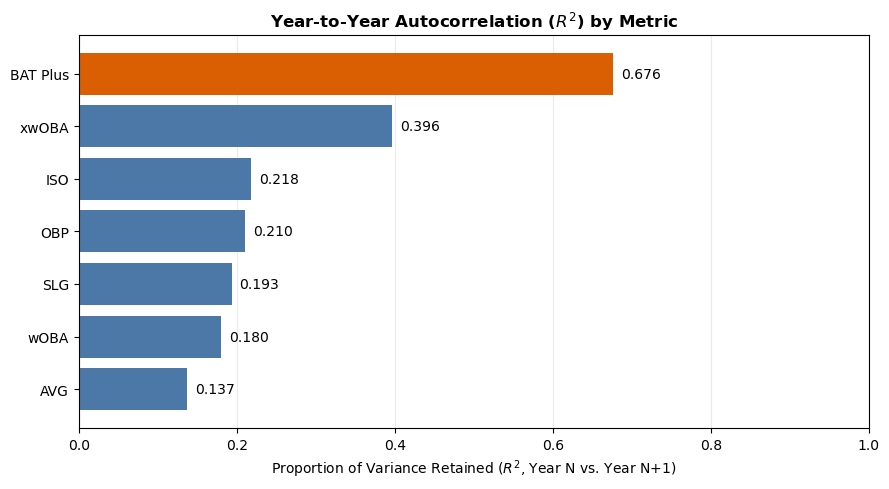

In [7]:
# Plot the Year N-to-N+1 R^2 (derived from Pearson r) for each metric; highlight BAT Plus.
plot_data = autocorrelation.copy()

# Compute R^2 directly from Pearson correlation r
plot_data['R2_from_r'] = plot_data['Autocorrelation (r)'] ** 2
plot_data = plot_data.sort_values('R2_from_r')

colors = np.where(plot_data['Metric'].eq('BAT Plus'), '#d95f02', '#4c78a8')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_data['Metric'], plot_data['R2_from_r'], color=colors)
ax.set_title('Year-to-Year Autocorrelation ($R^2$) by Metric', weight='bold')
ax.set_xlabel('Proportion of Variance Retained ($R^2$, Year N vs. Year N+1)')
ax.set_xlim(0, max(1.0, plot_data['R2_from_r'].max() + 0.08))
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)

# Add exact R^2 values as data labels.
for bar, value in zip(bars, plot_data['R2_from_r']):
    ax.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center')

plt.tight_layout()
plt.show()

## 7. Export player-level results

The export contains the core model inputs, BAT Plus score, and selected outcome metrics for downstream analysis.

In [8]:
export_cols = [
    'season', 'name', 'fast_swing_rate_z', 'contact_index_z', 'decision_index_z',
    'bat_plus', 'obp', 'woba',
]
export_path = Path('batplus_player_results.csv')
data.loc[:, export_cols].to_csv(export_path, index=False)
print(f'Exported {len(data):,} player-season records to {export_path.name}.')

Exported 1,764 player-season records to batplus_player_results.csv.


## Conclusion

BAT Plus combines fast-swing rate, heart-contact rate, and a regression-weighted swing-decision index into a season-adjusted batting-quality score. The consecutive-season comparison shows that **BAT Plus has great autocorrelation**, supporting its usefulness as a stable measure of player batting quality across seasons.